In [1]:
"..."

'...'

In [2]:
import torch
from torch.nn import functional as F
from spehere_encoder_cifra_10 import CIFAR10AutoencoderDataset
from models.vit import Model
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt


In [3]:

batch_size = 64
img_size = 32
patch_size = 2
in_channels = 3
hidden_dim = 384
latent_channels = 8
num_classes = 10
num_heads = 6
depth = 12


dataset = CIFAR10AutoencoderDataset(train=False)
data_loader = DataLoader(dataset, batch_size=64)

model = Model(
    img_size=img_size, 
    patch_size=patch_size, 
    in_channels=in_channels, 
    hidden_dim=hidden_dim, 
    latent_channels=latent_channels,
    num_classes=num_classes,
    num_heads=num_heads,
    depth=depth,
)

/home/daniel/home/sph_encoder/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
checkpoint = torch.load("/home/daniel/home/sph_encoder/runs9/cifar10_test/interrupted_latest.pt")

In [5]:
# checkpoint['model_state']
model.load_state_dict(checkpoint['model_state'])

<All keys matched successfully>

In [6]:
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt

def show_tensor_images(image_tensor, num_images=16, size=(3, 32, 32)):
    '''
    Function for visualizing images: Given a tensor of images, number of images, and
    size per image, plots and prints the images in a uniform grid.
    '''
    # Unflatten the batch if necessary and detach from graph
    image_unflattened = image_tensor.detach().cpu().view(-1, *size)
    
    # Create a grid
    image_grid = vutils.make_grid(image_unflattened, nrow=4)
    
    # Matplotlib expects channels last (H, W, C)
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())
    plt.axis('off')
    plt.show()

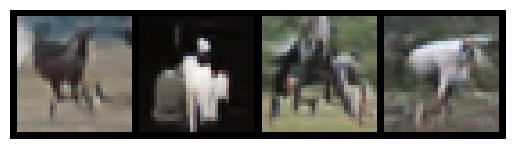

In [9]:
cfg_scale=2.0
do_enc_cfg=False
do_dec_cfg=False
T=4
r=1.0

seq_len = (img_size // patch_size) ** 2
with torch.inference_mode():
    samples = model.spherefiy.sample(
        model.encoder, 
        model.decoder, 
        latent_shape=(4, seq_len, latent_channels), 
        class_label=torch.tensor([7] * 4, device="cpu"), 
        cfg_scale=2.0, do_enc_cfg=True, 
        do_dec_cfg=True, 
        T=4, 
        r=1.0, 
        device="cpu"
    )

show_tensor_images((samples + 1).contiguous() / 2, num_images=4, size=(3, img_size, img_size))

In [16]:
dataset = CIFAR10AutoencoderDataset(train=False)
x, label = dataset[16]
model.eval()
with torch.inference_mode():
    samples = model.forward(x.unsqueeze(0), torch.tensor([label]))

### 20 epoches

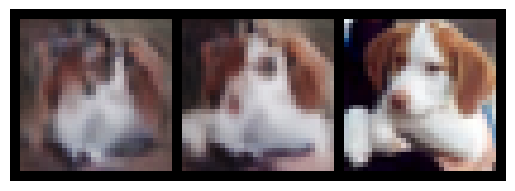

In [31]:
show_tensor_images(torch.concat([((samples[txt] + 1) / 2)[index] for txt in ["x_NOISY", "x_noisy", "x"]]), num_images=16, size=(3, img_size, img_size))

### 34 epoches

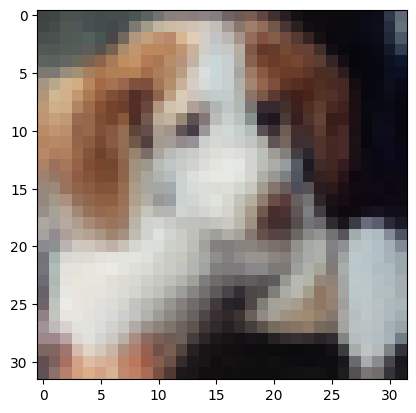

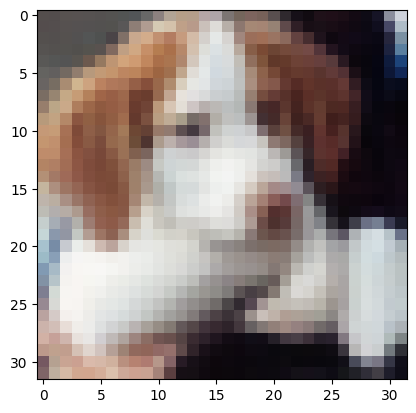

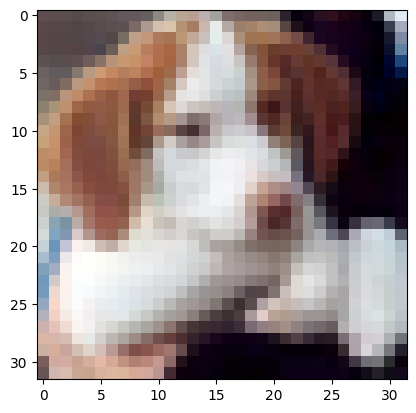

In [53]:
index = 16
plt.imshow(((samples['x_NOISY'] + 1) / 2)[index].permute(1, 2, 0).numpy())
plt.show()
plt.imshow(((samples['x_noisy'] + 1) / 2)[index].permute(1, 2, 0).numpy())
plt.show()
plt.imshow(((samples['x'] + 1) / 2)[index].permute(1, 2, 0).numpy())
plt.show()